# Evaluación 2

**Programación Científica 2026-1 · Universidad Nacional de Colombia** — mbastidaso@unal.edu.co

**Modalidad:** individual · **Entrega:** GitHub (rama + Pull Request)

> ⚙️ **Enunciado personalizado — ID 5159.** Los parámetros son únicos.

---

## Idea central

Este semestre aproximamos funciones como combinación de bases, $\hat f(t)=\sum_i c_i\phi_i(t)$.

Una **red neuronal** hace lo mismo, pero **aprende** sus propias bases en vez de fijarlas.

En esta evaluación construimos una red que **reconstruye** una señal, y estudiamos qué pasa cuando su **primera capa es la Transformada de Fourier**.

La pregunta que guía todo: *¿ayuda empezar con la base "correcta" (Fourier) en lugar de una base aleatoria?*

---

# Parte I — El fenómeno

## 1. Ondas que se dispersan

En un medio **sin dispersión** todas las frecuencias viajan igual y una onda mantiene su forma. En un medio **dispersivo**, distintas frecuencias viajan a distinta velocidad: es lo que separa los colores en un prisma, deforma un pulso en una fibra óptica, y hace que las olas largas lleguen antes que las cortas. Los datos vienen de un medio dispersivo.

## 2. La regla del medio

Una onda se compone de **modos**, cada uno con un número entero $k$ (su número de onda). La regla asigna a cada modo una **frecuencia** $\omega(k)$:

$$\omega(k) = \sqrt{c^2 k^2 + \mu^2}.$$

Esta información es dada: Si $\mu=0$ las frecuencias son bajas; si $\mu>0$, el término $\mu^2$ **empuja las frecuencias hacia arriba** (mayor $\mu$, oscilaciones más rápidas). El parámetro $\mu$ define **tres regímenes** (las etiquetas `y` de los datos): 0 = sin dispersión (frecuencias bajas), 1 = intermedia, 2 = fuerte (frecuencias altas).

## 3. Lo que medimos

Un sensor fijo registra la suma de los modos en el tiempo:

$$f(t) = \sum_j a_j \cos\bigl(\omega(k_j)\,t + \varphi_j\bigr).$$

**Cada señal es una suma de cosenos a frecuencias bien definidas**, justo lo que una base de senos y cosenos representa con pocos coeficientes.

---

# Parte II — Los datos

Generar los datos con los 4 últimos dígitos del ID (script aparte) y cargarlos.

El conjunto tiene **15 señales por régimen** (45 en total).

---

# Parte III — La red

Construir, **en JAX**, una red que recibe una señal $x\in\mathbb{R}^{256}$ y la **reconstruye** (su salida $\hat x$ debe parecerse a $x$).

La red se entrena minimizando el error (media cuadrática) entre la señal original y la reconstruida:

$$\mathcal{L} = \tfrac1N\|\hat x - x\|^2$$

## La arquitectura

La red tiene dos capas. La **primera** es una capa lineal de tamaño $256 \to 2K$ (con **K = 30** frecuencias) seguida de una no linealidad $\tanh$; la **siguiente** es una capa lineal $2K \to 256$ que reconstruye la señal:

$$\hat x = W_2\,\tanh(W_1 x).$$

La idea central está en $W_1$. Sus pesos pueden **inicializarse como la matriz de Fourier**: las filas son $\sin(2\pi k t)$ y $\cos(2\pi k t)$, $k=1,\dots,30$ o de forma **aleatoria**. En ambos casos $W_1$ se sigue entrenando: lo único que cambia es el punto de partida.

## Lo que se espera

Este trabajo debe permitir responder, con evidencia propia, si conviene arrancar la red en la base de Fourier en lugar de una base aleatoria. Para ello:

- Construir la capa Fourier y verificar que, en su punto de partida, calcula efectivamente una transformada de Fourier de la señal.
- Entrenar la red con las **dos inicializaciones** (Fourier y aleatoria) sobre señales de los tres regímenes, durante **4000 iteraciones** (learning rate sugerido $\eta=0.05$), y estudiar la evolución de la pérdida (error) en cada caso.
- Prestar especial atención al **régimen 2** y a la **velocidad** con que cada inicialización mejora.
- Explorar cuánta información de la señal vive en pocos coeficientes de la capa Fourier (compresión, con referencia al **95%** de la energía).

Las gráficas y resultados concretos que se deben entregar están en la **rúbrica** (documento de instrucciones de la evaluación).


# Entrega por GitHub

1. Rama propia: `git checkout -b eval2-APELLIDOS`
2. Carpeta con los **apellidos** en la raíz del repositorio:
   ```
   PerezGomez/
   ├── solucion.ipynb        # el notebook resuelto
   ├── enunciado_5159.md   # el enunciado personalizado
   └── datos_5159.npz      # los datos
   ```
3. **Varios Commits semánticos** (`feat:`, `fix:`, `docs:`, `data:`) no un único commit final.
4. Abre un **Pull Request** con una descripicón corta del trabajo.

> 📊 ** Acumulativo.** Este curso se evalúa de forma acumulativa, siempre debemos dar especial énfasis en visualización científica: ejes con unidades, tipo de gráfico y mapa de color justificados, leyendas claras, figuras que comuniquen una idea. Una reconstrucción correcta en una figura pobre no recibe puntaje completo.


In [6]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd   # <-- NUEVO: para la tabla

# Configuración visual para las gráficas
plt.style.use('seaborn-v0_8-whitegrid')

In [7]:
# Configuración de texto con estilo LaTeX (sin necesidad de instalar LaTeX en el sistema)
plt.rcParams.update({
    # Si tienes LaTeX instalado y quieres usarlo, cambia esto a True
    "text.usetex": False,

    # Fuente serif (similar a la de LaTeX)
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Computer Modern", "Times New Roman"],

    # Fuente matemática con estilo STIX (muy parecida a LaTeX)
    "mathtext.fontset": "stix",

    # Tamaños de fuente para una mejor legibilidad
    "axes.labelsize": 12,
    "font.size": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    # Configuración de los ejes
    "axes.titlesize": 14,
    "axes.titleweight": "bold",

    # Mejora la calidad de las figuras
    "figure.dpi": 120,
    "savefig.dpi": 300,
})

In [8]:
# 1. Carga de datos y reporte de energía media
datos = np.load('datos_5159.npz')
key = datos.files[0]
X = datos[key] # Matriz de 45 x 256 señales

energia_media = jnp.mean(X**2)
print(f"Energía media del dataset: {energia_media:.3f}")

Energía media del dataset: 0.699


In [9]:
# 2. Configuración de parámetros y funciones de inicialización
N = X.shape[1] # 256
K = 30
hidden_size = 2 * K # 60
eta = 0.05
iteraciones = 4000

def init_fourier(N, K):
    W = np.zeros((N, 2 * K))
    t = np.arange(N)
    for k in range(1, K + 1):
        W[:, 2*k - 2] = np.cos(2 * np.pi * k * t / N)
        W[:, 2*k - 1] = np.sin(2 * np.pi * k * t / N)
    return jnp.array(W)

def init_random(N, hidden_size):
    np.random.seed(42)
    return jnp.array(np.random.uniform(-0.1, 0.1, (N, hidden_size)))

W1_fourier = init_fourier(N, K)
W1_random = init_random(N, hidden_size)
W2_init = jnp.array(np.random.uniform(-0.1, 0.1, (hidden_size, N)))

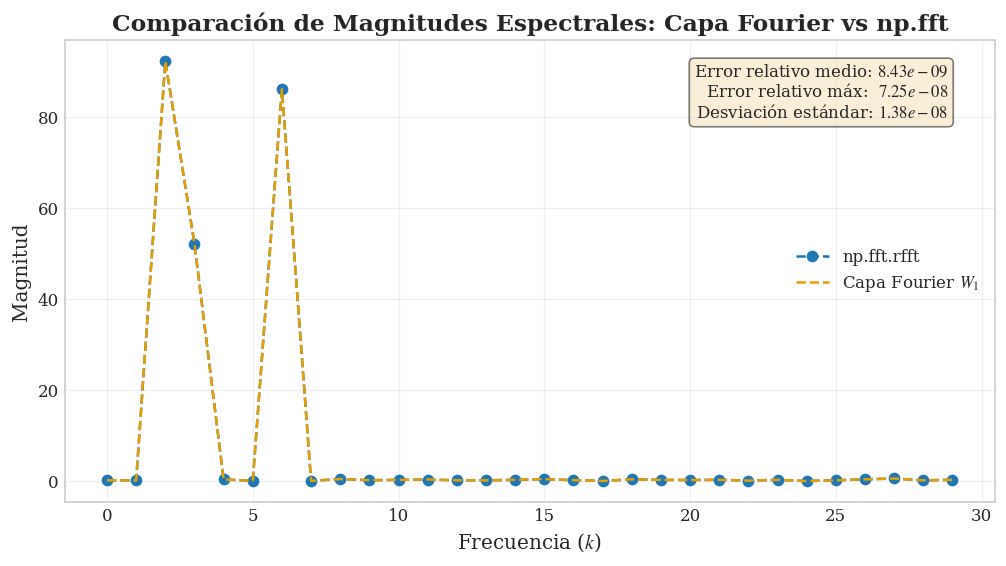

In [66]:
# 3. Verificación empírica de la Capa Fourier vs np.fft
senal_prueba = X[0]
coefs_red = senal_prueba @ W1_fourier

coefs_fft = np.fft.rfft(senal_prueba)
magnitud_fft = np.abs(coefs_fft[1:K+1])
magnitud_red = np.sqrt(coefs_red[0::2]**2 + coefs_red[1::2]**2)

error_abs = np.abs(magnitud_fft - magnitud_red)
error_rel = error_abs / (np.max(magnitud_fft) + 1e-12)

# Estadísticas
media_error = np.mean(error_rel)
max_error = np.max(error_rel)
std_error = np.std(error_rel)

plt.figure(figsize=(10, 5))
plt.plot(magnitud_fft, 'o--', label=r'np.fft.rfft', color='#1f77b4', markersize=6, linewidth=1.5)
plt.plot(magnitud_red, '--', label=r'Capa Fourier $W_1$', color='#E69F00', markersize=6, linewidth=1.5)

# Recuadro con estadísticas
textstr = '\n'.join((
    r'Error relativo medio: $%.2e$' % media_error,
    r'Error relativo máx:  $%.2e$' % max_error,
    r'Desviación estándar: $%.2e$' % std_error
))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
plt.text(0.95, 0.95, textstr, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', horizontalalignment='right', bbox=props)

plt.title(r'Comparación de Magnitudes Espectrales: Capa Fourier vs np.fft')
plt.xlabel(r'Frecuencia ($k$)')
plt.ylabel(r'Magnitud')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

In [40]:
# 4. Funciones de pérdida y bucle de entrenamiento
def predict(W1, W2, x):
    return jnp.tanh(x @ W1) @ W2

def loss_fn(W1, W2, x):
    return jnp.mean((predict(W1, W2, x) - x)**2)

grad_loss = jax.grad(loss_fn, argnums=(0, 1))

def calcular_error_relativo(X_true, X_pred):
    return jnp.linalg.norm(X_pred - X_true, axis=1) / jnp.linalg.norm(X_true, axis=1)

def train(W1_ini, W2_ini, X_train, iters, lr):
    W1, W2 = W1_ini, W2_ini
    hist_loss, hist_err = [], []
    for i in range(iters):
        g1, g2 = grad_loss(W1, W2, X_train)
        W1 -= lr * g1
        W2 -= lr * g2

        if i % 50 == 0 or i == iters - 1:
            curr_loss = loss_fn(W1, W2, X_train)
            curr_err = calcular_error_relativo(X_train, predict(W1, W2, X_train)).mean()
            hist_loss.append((i, curr_loss))
            hist_err.append((i, curr_err))
    return W1, W2, jnp.array(hist_loss), jnp.array(hist_err)

print("Entrenando red con inicialización Fourier...")
W1_f, W2_f, loss_f, err_f = train(W1_fourier, W2_init, X, iteraciones, eta)

print("Entrenando red con inicialización Aleatoria...")
W1_r, W2_r, loss_r, err_r = train(W1_random, W2_init, X, iteraciones, eta)
print("Entrenamiento completado.")

Entrenando red con inicialización Fourier...
Entrenando red con inicialización Aleatoria...
Entrenamiento completado.


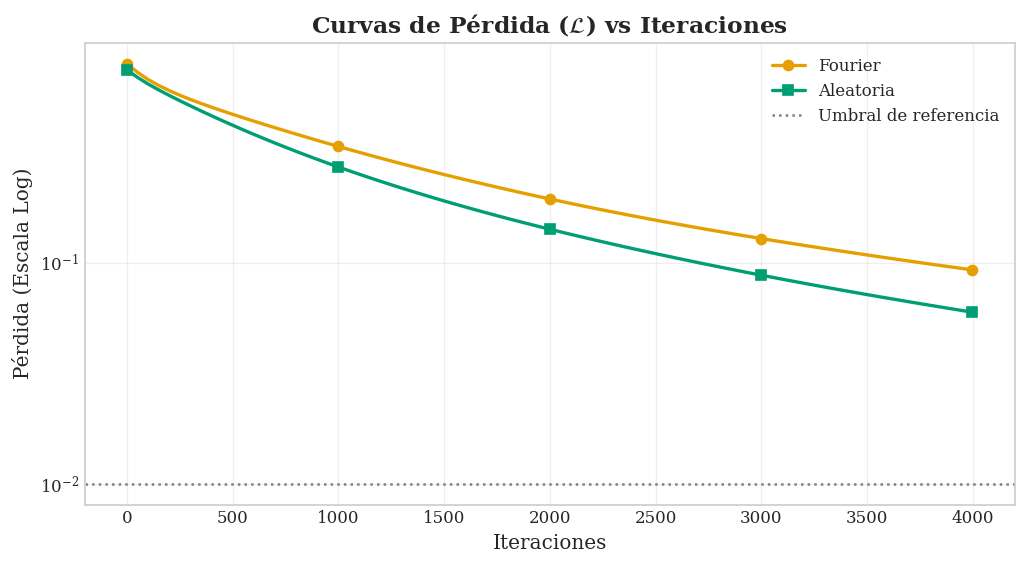

In [65]:
plt.figure(figsize=(10, 5))
plt.plot(loss_f[:, 0], loss_f[:, 1],color ="#E69F00", label='Fourier', linewidth=2, marker='o', markevery=20)
plt.plot(loss_r[:, 0], loss_r[:, 1],color = "#009E73", label='Aleatoria', linewidth=2, marker='s', markevery=20)
plt.axhline(y=0.01, color='gray', linestyle=':', label='Umbral de referencia')  # Ajusta el valor
plt.title(r'Curvas de Pérdida ($\mathcal{L}$) vs Iteraciones')
plt.xlabel('Iteraciones')
plt.ylabel(r'Pérdida (Escala Log)')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Error relativo final Régimen 2: Fourier=0.3777, Aleatoria=0.3008


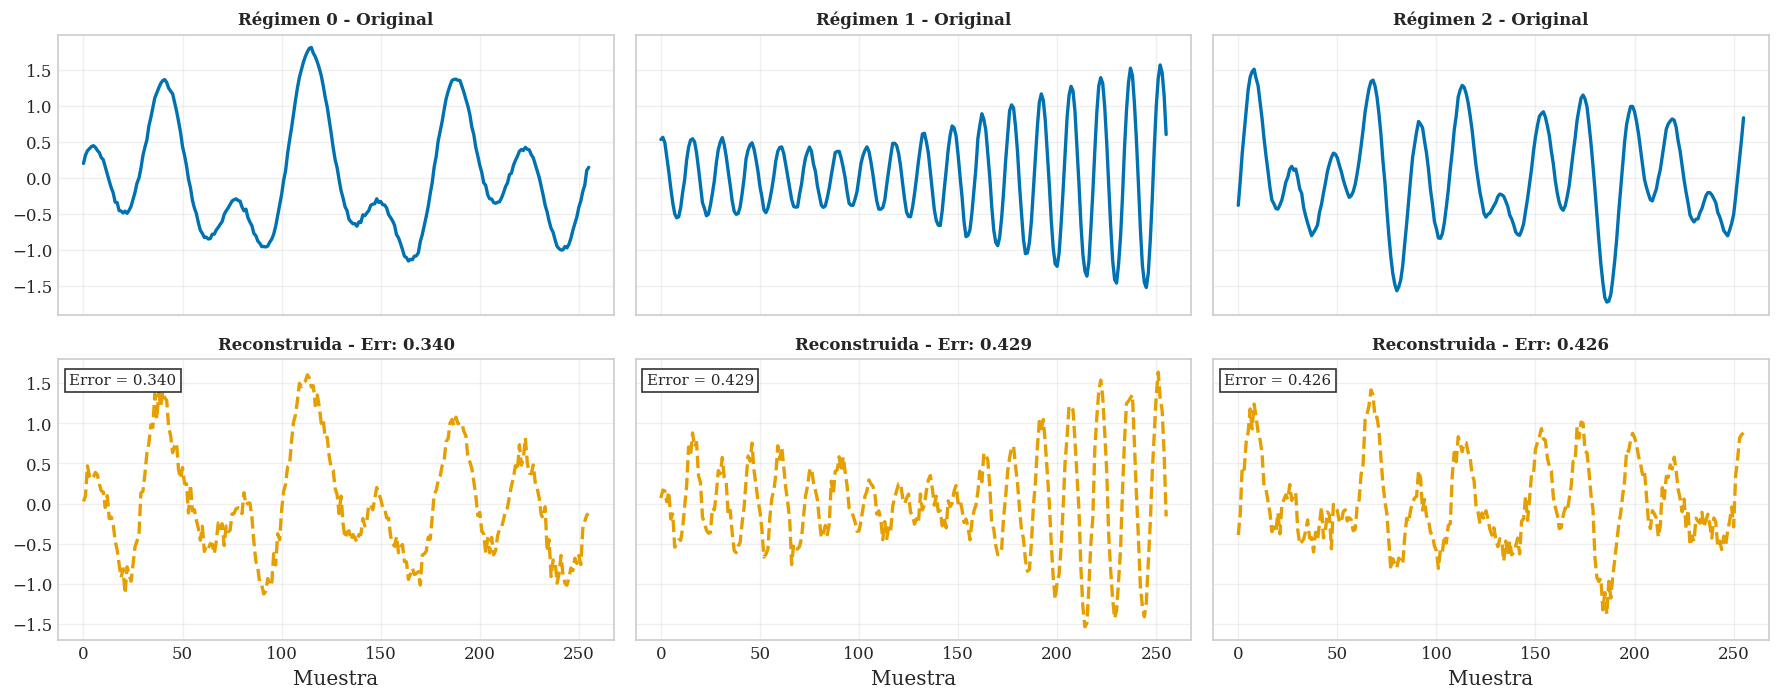

In [64]:
# 6. Análisis específico del Régimen 2 y Reconstrucciones
X_regimen2 = X[30:45]
err_reg2_fourier = calcular_error_relativo(X_regimen2, predict(W1_f, W2_f, X_regimen2)).mean()
err_reg2_random = calcular_error_relativo(X_regimen2, predict(W1_r, W2_r, X_regimen2)).mean()
print(f"Error relativo final Régimen 2: Fourier={err_reg2_fourier:.4f}, Aleatoria={err_reg2_random:.4f}")

indices = [0, 15, 30]
fig, axs = plt.subplots(2, 3, figsize=(15, 6), sharex='col', sharey='row')

for col, idx in enumerate(indices):
    x_orig = X[idx:idx+1]
    x_recon = predict(W1_f, W2_f, x_orig)
    err = calcular_error_relativo(x_orig, x_recon)[0]

    # Fila superior: original
    axs[0, col].plot(x_orig[0], color='#0072B2', linewidth=2)
    axs[0, col].set_title(f'Régimen {col} - Original', fontsize=10)
    axs[0, col].grid(True, alpha=0.3)

    # Fila inferior: reconstruida
    axs[1, col].plot(x_recon[0], color='#E69F00', linewidth=2, linestyle='--')
    axs[1, col].set_title(f'Reconstruida - Err: {err:.3f}', fontsize=10)
    axs[1, col].grid(True, alpha=0.3)
    axs[1, col].set_xlabel('Muestra')

    # Añadir el error en la esquina de la fila inferior
    axs[1, col].text(0.02, 0.95, f'Error = {err:.3f}', transform=axs[1, col].transAxes,
                     fontsize=9, va='top',
                     bbox=dict(boxstyle='square', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

In [54]:
# 7. Reporte sistemático de errores por régimen
def error_por_regimen(W1, W2, X, regimen_indices):
    X_reg = X[regimen_indices]
    X_pred = predict(W1, W2, X_reg)
    return calcular_error_relativo(X_reg, X_pred).mean()

regimenes = {
    'Régimen 0': slice(0, 15),
    'Régimen 1': slice(15, 30),
    'Régimen 2': slice(30, 45)
}

errores_fourier = {reg: error_por_regimen(W1_f, W2_f, X, idx) for reg, idx in regimenes.items()}
errores_aleatorio = {reg: error_por_regimen(W1_r, W2_r, X, idx) for reg, idx in regimenes.items()}

df_errores = pd.DataFrame({
    'Fourier': errores_fourier,
    'Aleatoria': errores_aleatorio
})
print("Errores relativos promedio por régimen:")
print(df_errores.round(4))

Errores relativos promedio por régimen:
              Fourier   Aleatoria
Régimen 0  0.36247745  0.30616847
Régimen 1  0.37961692    0.309993
Régimen 2  0.37769637  0.30083102


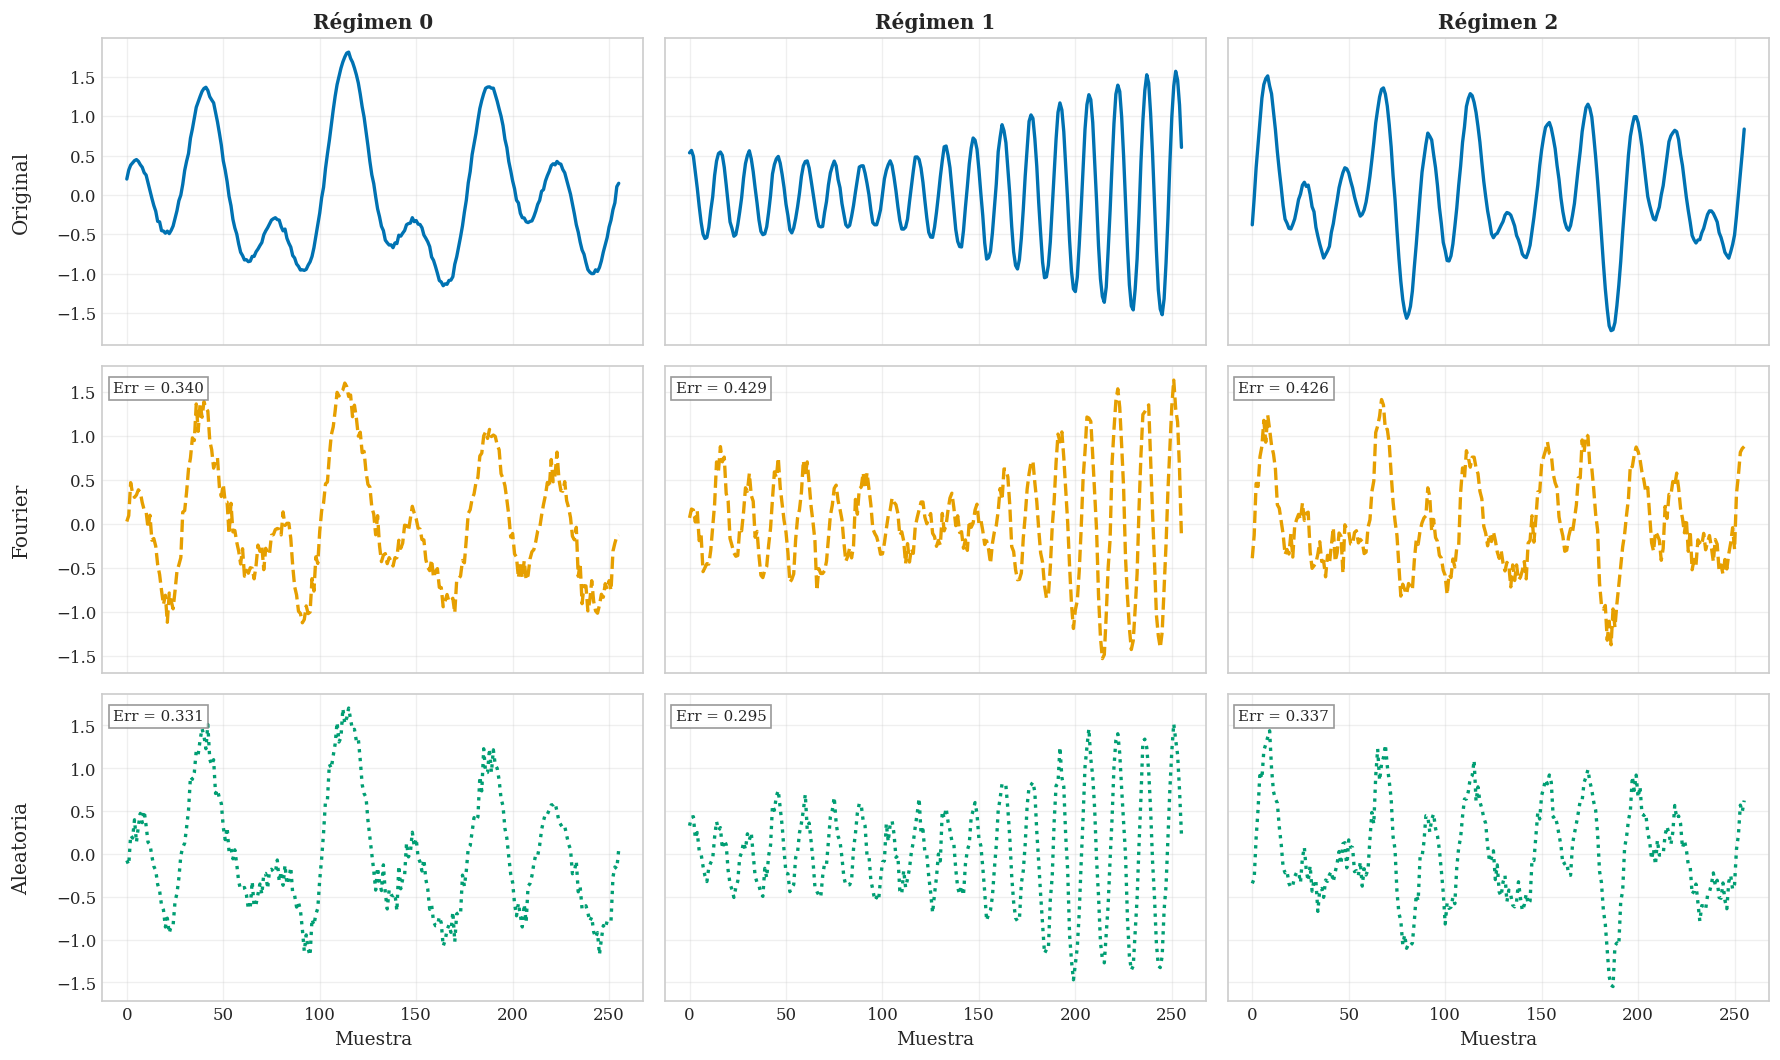

In [63]:
# 8. Reconstrucciones: Cuadrícula 3x3 (cada señal en su propio subplot)
regimes = [0, 15, 30]
labels = ['Original', 'Fourier', 'Aleatoria']
colors = ['#0072B2', '#E69F00', '#009E73']
linestyles = ['-', '--', ':']

# Crear la cuadrícula: 3 filas (señales) x 3 columnas (regímenes)
fig, axs = plt.subplots(3, 3, figsize=(15, 9), sharex='col', sharey='row')

for col, idx in enumerate(regimes):
    x_orig = X[idx:idx+1]
    x_rec_f = predict(W1_f, W2_f, x_orig)
    x_rec_r = predict(W1_r, W2_r, x_orig)

    err_f = calcular_error_relativo(x_orig, x_rec_f)[0]
    err_r = calcular_error_relativo(x_orig, x_rec_r)[0]

    # Datos de cada fila para esta columna
    signals = [x_orig[0], x_rec_f[0], x_rec_r[0]]
    errs = ['', f'Err = {err_f:.3f}', f'Err = {err_r:.3f}']

    for row in range(3):
        ax = axs[row, col]
        ax.plot(signals[row], color=colors[row], linestyle=linestyles[row], linewidth=2)
        ax.grid(True, alpha=0.3)

        # Título de la columna (solo en la primera fila)
        if row == 0:
            ax.set_title(f'Régimen {col}', fontsize=12, fontweight='bold')

        # Mostrar el error en los subplots de reconstrucción
        if row > 0:
            ax.text(0.02, 0.95, errs[row], transform=ax.transAxes,
                    fontsize=9, va='top',
                    bbox=dict(boxstyle='square', facecolor='white', alpha=0.8, edgecolor='gray'))

        # Configurar el rango de Y para que todas las filas compartan la misma escala
        # (ya se hace automáticamente con sharey='row')

# Etiquetas de las filas (a la izquierda)
for row, label in enumerate(labels):
    axs[row, 0].set_ylabel(label, fontsize=12, rotation=90, labelpad=15)

# Etiqueta X para la fila inferior
for col in range(3):
    axs[2, col].set_xlabel('Muestra', fontsize=11)

# Ajustar layout y mostrar
plt.tight_layout()
plt.show()

In [67]:
# 9. Función de entrenamiento que guarda evolución del error en régimen 2
def train_con_regimen(W1_ini, W2_ini, X_train, X_reg2, iters, lr):
    W1, W2 = W1_ini, W2_ini
    hist_loss, hist_err_global, hist_err_reg2 = [], [], []
    for i in range(iters):
        g1, g2 = grad_loss(W1, W2, X_train)
        W1 -= lr * g1
        W2 -= lr * g2

        if i % 50 == 0 or i == iters - 1:
            curr_loss = loss_fn(W1, W2, X_train)
            curr_err_global = calcular_error_relativo(X_train, predict(W1, W2, X_train)).mean()
            curr_err_reg2 = calcular_error_relativo(X_reg2, predict(W1, W2, X_reg2)).mean()
            hist_loss.append((i, curr_loss))
            hist_err_global.append((i, curr_err_global))
            hist_err_reg2.append((i, curr_err_reg2))
    return W1, W2, jnp.array(hist_loss), jnp.array(hist_err_global), jnp.array(hist_err_reg2)

In [68]:
# 10. Reentrenamiento para obtener curvas de error en régimen 2
X_reg2 = X[30:45]

print("Reentrenando con Fourier (con seguimiento régimen 2)...")
W1_f2, W2_f2, loss_f2, err_f_global2, err_f_reg2 = train_con_regimen(
    W1_fourier, W2_init, X, X_reg2, iteraciones, eta)

print("Reentrenando con Aleatoria (con seguimiento régimen 2)...")
W1_r2, W2_r2, loss_r2, err_r_global2, err_r_reg2 = train_con_regimen(
    W1_random, W2_init, X, X_reg2, iteraciones, eta)
print("Reentrenamiento completado.")

Reentrenando con Fourier (con seguimiento régimen 2)...
Reentrenando con Aleatoria (con seguimiento régimen 2)...
Reentrenamiento completado.


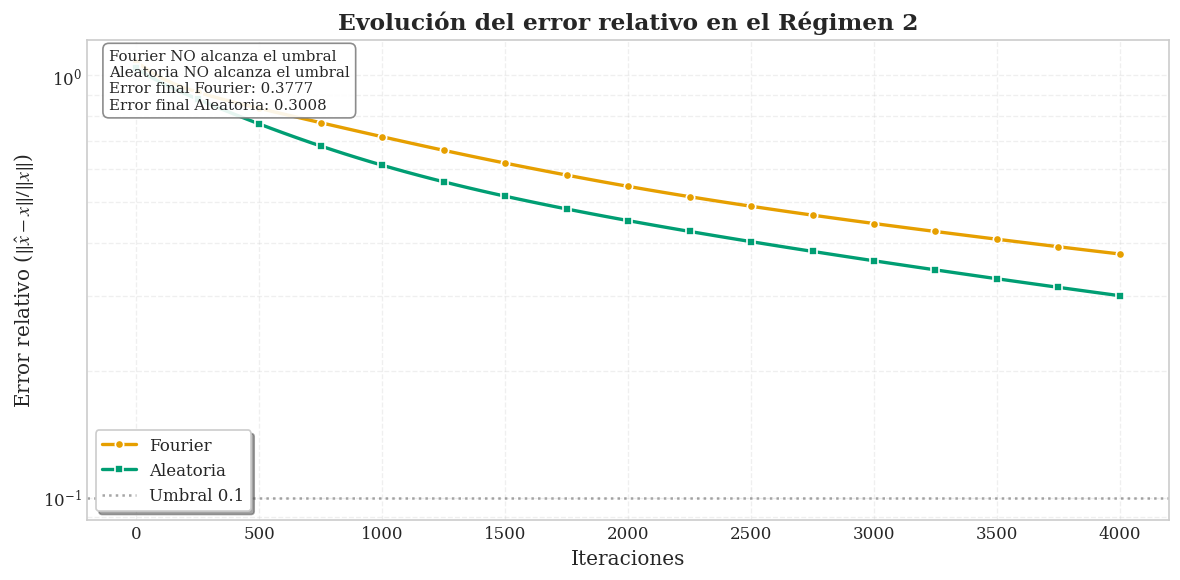

In [74]:
# 11. Gráfica de convergencia del error relativo en el régimen 2 (mejorada)
plt.figure(figsize=(10, 5))

# Colores Okabe-Ito
color_fourier = '#E69F00'  # Naranja/Amarillo (Fourier)
color_random = '#009E73'   # Verde azulado (Aleatoria)

# Calcular marcadores cada cierto número de iteraciones
markevery = max(1, len(err_f_reg2) // 15)  # Aprox 15 marcadores por curva

# Graficar Fourier
plt.plot(err_f_reg2[:, 0], err_f_reg2[:, 1],
         label='Fourier', color=color_fourier, linewidth=2,
         marker='o', markevery=markevery, markersize=5, markeredgecolor='white')

# Graficar Aleatoria
plt.plot(err_r_reg2[:, 0], err_r_reg2[:, 1],
         label='Aleatoria', color=color_random, linewidth=2,
         marker='s', markevery=markevery, markersize=5, markeredgecolor='white')

# --- Línea de umbral (error = 0.1) ---
plt.axhline(y=0.1, color='gray', linestyle=':', linewidth=1.5, alpha=0.7, label='Umbral 0.1')

# --- Calcular si y cuándo se alcanza el umbral en régimen 2 ---
idx_f_reg2 = jnp.where(err_f_reg2[:, 1] < 0.1)[0]
idx_r_reg2 = jnp.where(err_r_reg2[:, 1] < 0.1)[0]
iter_f_reg2 = err_f_reg2[idx_f_reg2[0], 0] if len(idx_f_reg2) > 0 else None
iter_r_reg2 = err_r_reg2[idx_r_reg2[0], 0] if len(idx_r_reg2) > 0 else None

# --- Preparar texto para el recuadro de estadísticas ---
stats_lines = []
if iter_f_reg2 is not None:
    stats_lines.append(f'Fourier alcanza en iter {int(iter_f_reg2)}')
else:
    stats_lines.append('Fourier NO alcanza el umbral')
if iter_r_reg2 is not None:
    stats_lines.append(f'Aleatoria alcanza en iter {int(iter_r_reg2)}')
else:
    stats_lines.append('Aleatoria NO alcanza el umbral')

# Añadir errores finales
err_f_final = err_f_reg2[-1, 1]
err_r_final = err_r_reg2[-1, 1]
stats_lines.append(f'Error final Fourier: {err_f_final:.4f}')
stats_lines.append(f'Error final Aleatoria: {err_r_final:.4f}')

# --- Recuadro con estadísticas ---
props = dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9, edgecolor='gray')
plt.text(0.02, 0.98, '\n'.join(stats_lines), transform=plt.gca().transAxes,
         fontsize=9, verticalalignment='top', bbox=props)

# --- Configurar escala logarítmica en Y ---
plt.yscale('log')

# --- Etiquetas y título con LaTeX ---
plt.title(r'Evolución del error relativo en el Régimen 2', fontsize=14, fontweight='bold')
plt.xlabel('Iteraciones', fontsize=12)
plt.ylabel(r'Error relativo ($\|\hat{x} - x\| / \|x\|$)', fontsize=12)

# --- Leyenda ---
plt.legend(loc='lower left', frameon=True, fancybox=True, shadow=True)

# --- Grid más suave ---
plt.grid(True, alpha=0.3, linestyle='--', which='both')

# Ajustar layout y mostrar
plt.tight_layout()
plt.show()



In [78]:
# Celda: Iteraciones para error < 0.1 en Régimen 2
idx_f_reg2 = jnp.where(err_f_reg2[:, 1] < 0.1)[0]
idx_r_reg2 = jnp.where(err_r_reg2[:, 1] < 0.1)[0]

iter_f_reg2 = err_f_reg2[idx_f_reg2[0], 0] if len(idx_f_reg2) > 0 else 'No alcanza'
iter_r_reg2 = err_r_reg2[idx_r_reg2[0], 0] if len(idx_r_reg2) > 0 else 'No alcanza'
print(f'Iteraciones para error < 0.1 en Régimen 2: Fourier={iter_f_reg2}, Aleatoria={iter_r_reg2}')

Iteraciones para error < 0.1 en Régimen 2: Fourier=No alcanza, Aleatoria=No alcanza


Coeficientes necesarios para retener el 95% de energía: 54 de 60


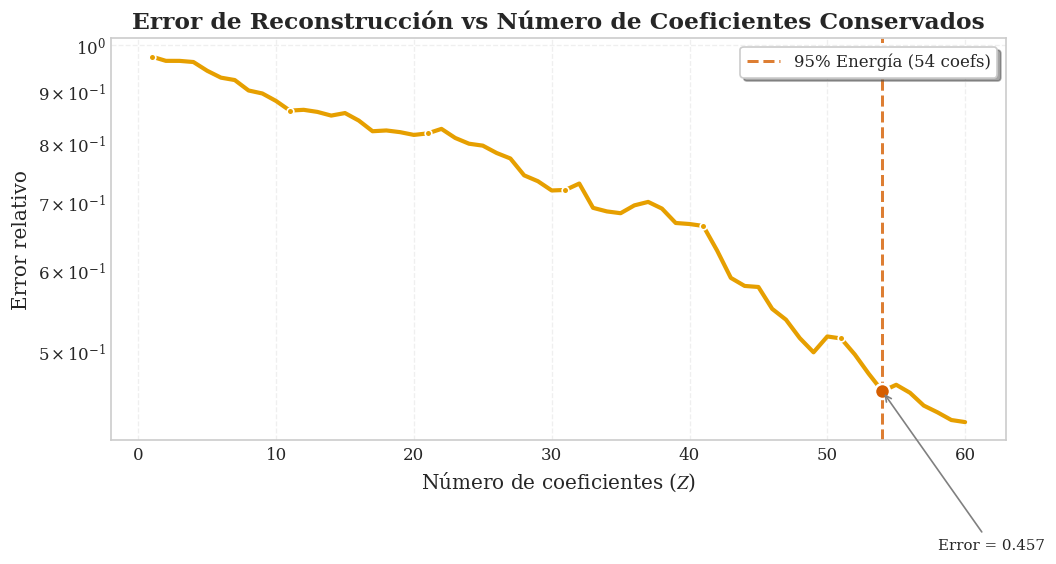

Error con 54 coeficientes: 0.4573
Compresión lograda: 10.0%


In [76]:
# 13. Evaluación de Compresión (95% de energía) - Versión simplificada
x_eval = X[30]  # Usamos una señal del Régimen 2
z = jnp.tanh(x_eval @ W1_f)
z_magnitud = np.abs(z)

indices_ordenados = np.argsort(z_magnitud)[::-1]
energia_total = np.sum(z**2)
energia_acumulada = np.cumsum(z[indices_ordenados]**2) / energia_total

num_coefs_95 = np.argmax(energia_acumulada >= 0.95) + 1
print(f"Coeficientes necesarios para retener el 95% de energía: {num_coefs_95} de {hidden_size}")

# Calcular errores de compresión
errores_compresion = []
for n in range(1, len(z) + 1):
    z_comprimido = jnp.zeros_like(z)
    z_comprimido = z_comprimido.at[indices_ordenados[:n]].set(z[indices_ordenados[:n]])
    x_reconstruida = z_comprimido @ W2_f
    error = jnp.linalg.norm(x_reconstruida - x_eval) / jnp.linalg.norm(x_eval)
    errores_compresion.append(error)

# --- Gráfica simplificada ---
plt.figure(figsize=(9, 5))

# Colores Okabe-Ito
color_curve = '#E69F00'    # Naranja (Fourier)
color_vline = '#D55E00'    # Rojo anaranjado para la línea vertical

# Curva de error
plt.plot(range(1, len(z) + 1), errores_compresion,
         color=color_curve, linewidth=2.5,
         marker='o', markersize=4, markevery=10, markeredgecolor='white')

# Línea vertical en el umbral del 95% de energía
plt.axvline(x=num_coefs_95, color=color_vline, linestyle='--', linewidth=1.8,
            alpha=0.8, label=f'95% Energía ({num_coefs_95} coefs)')

# Punto destacado en la intersección
error_at_95 = errores_compresion[num_coefs_95 - 1]
plt.plot(num_coefs_95, error_at_95, 'o', color=color_vline, markersize=9,
         markeredgecolor='white', markeredgewidth=1.5)

# Anotación del punto (solo el valor del error)
plt.annotate(f'Error = {error_at_95:.3f}',
             xy=(num_coefs_95, error_at_95),
             xytext=(num_coefs_95 + 4, error_at_95 * 0.7),
             arrowprops=dict(arrowstyle='->', color='gray', lw=1),
             fontsize=9)

# Configuración de ejes y títulos
plt.title('Error de Reconstrucción vs Número de Coeficientes Conservados',
          fontsize=14, fontweight='bold')
plt.xlabel(r'Número de coeficientes ($Z$)', fontsize=12)
plt.ylabel(r'Error relativo', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)

# Escala semilog para apreciar mejor los cambios
plt.yscale('log')

plt.tight_layout()
plt.show()

# --- Imprimir información clave en consola ---
print(f"Error con {num_coefs_95} coeficientes: {error_at_95:.4f}")
print(f"Compresión lograda: {100 * (1 - num_coefs_95/len(z)):.1f}%")